# PyTorch Dataset, model, validacija i eksperimenti

Od poruke pravimo tenzore i batch, treniramo sopstveni Transformer, proveravamo ga kroz pet fold-ova i upoređujemo pet arhitektura. Završni test skup ne čitamo.


## Mali primer sa dve poruke

Oznaka klase je druga vrsta broja od ID-ja tokena: `ham = 0`, `spam = 1`. Rečnik tokena gradimo samo iz poruka koje nam služe za učenje.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import torch
from torch.utils.data import DataLoader

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from src.sms_dataset import LABEL_TO_ID, SMSDataset
from src.vocabulary import build_vocabulary

toy = pd.DataFrame({"label": ["ham", "spam"], "text": ["See you soon", "Free prize now!"]})
toy_vocabulary = build_vocabulary(toy["text"])
toy_dataset = SMSDataset(toy, toy_vocabulary, max_length=8)
example = toy_dataset[1]
print("Mapiranje oznaka:", LABEL_TO_ID)
pd.DataFrame({
    "polje": list(example),
    "tip": [str(value.dtype) for value in example.values()],
    "vrednost": [value.tolist() for value in example.values()],
})

Mapiranje oznaka: {'ham': 0, 'spam': 1}


,polje,tip,vrednost
0,input_ids,torch.int64,"[3, 5, 4, 2, 0, 0, 0, 0]"
1,padding_mask,torch.bool,"[False, False, False, False, True, True, True,..."
2,label,torch.int64,1


U jednom primeru `input_ids` i `padding_mask` imaju po 8 vrednosti. `label` je jedan broj. Maska je tipa `torch.bool`; ID-jevi i oznaka su celobrojni tenzori.

In [2]:
toy_loader = DataLoader(toy_dataset, batch_size=2, shuffle=False)
toy_batch = next(iter(toy_loader))
pd.DataFrame({
    "polje": list(toy_batch),
    "oblik": [str(tuple(value.shape)) for value in toy_batch.values()],
    "tip": [str(value.dtype) for value in toy_batch.values()],
})

,polje,oblik,tip
0,input_ids,"(2, 8)",torch.int64
1,padding_mask,"(2, 8)",torch.bool
2,label,"(2,)",torch.int64


Prva dimenzija `2` znači dve poruke u batch-u, druga dimenzija `8` znači osam pozicija po poruci. Oblik oznaka je `(2,)`: po jedna oznaka za svaku poruku. `shuffle=False` ovde olakšava pregled; tokom stvarnog treniranja redosled ćemo mešati.

## Prvi batch iz trening skupa

Ovde gradimo rečnik samo iz `sms_train.csv`, pa pravimo `SMSDataset` nad istim trening porukama. Izdvojeni test se ne čita.

In [3]:
train = pd.read_csv(project_root / "data" / "processed" / "sms_train.csv")
vocabulary = build_vocabulary(train["text"])
train_dataset = SMSDataset(train, vocabulary, max_length=128)
train_batch = next(iter(DataLoader(train_dataset, batch_size=4, shuffle=False)))
print("Broj poruka u trening Dataset-u:", len(train_dataset))
print("Oblici:", {name: tuple(value.shape) for name, value in train_batch.items()})
print("Oznake prvog batch-a:", train_batch["label"].tolist())

Broj poruka u trening Dataset-u: 4127
Oblici: {'input_ids': (4, 128), 'padding_mask': (4, 128), 'label': (4,)}
Oznake prvog batch-a: [0, 0, 1, 0]


## Prvi prolaz kroz Transformer

Batch iz malog primera ulazi u embedding, Transformer encoder i klasifikator. Tačne oznake klasa ne ulaze u modelov `forward`; biće potrebne za računanje greške pri treniranju.

In [4]:
from src.model import SMSClassifier

print("ID-jevi:", toy_batch["input_ids"].tolist())
print("Maska:", toy_batch["padding_mask"].tolist())

ID-jevi: [[6, 8, 7, 0, 0, 0, 0, 0], [3, 5, 4, 2, 0, 0, 0, 0]]
Maska: [[False, False, False, True, True, True, True, True], [False, False, False, False, True, True, True, True]]


## Slojevi i oblici

Embedding za svaki token ima 64 broja. Pozicioni embedding iste dimenzije dodaje informaciju o redosledu. Dva Transformer bloka zatim računaju kontekstualne vektore. Prosek uzima samo stvarne tokene, a poslednji linearni sloj vraća **dva sirova skora** po poruci.

In [5]:
torch.manual_seed(42)
model = SMSClassifier(vocab_size=len(toy_vocabulary), max_length=8)
model.eval()
with torch.no_grad():
    token_vectors = model.token_embedding(toy_batch["input_ids"])
    positions = torch.arange(toy_batch["input_ids"].shape[1]).unsqueeze(0)
    position_vectors = model.position_embedding(positions)
    logits = model(toy_batch["input_ids"], toy_batch["padding_mask"])

pd.DataFrame({
    "deo": ["input_ids", "token embedding", "pozicioni embedding", "logits"],
    "oblik": [str(tuple(tensor.shape)) for tensor in (toy_batch["input_ids"], token_vectors, position_vectors, logits)],
})

,deo,oblik
0,input_ids,"(2, 8)"
1,token embedding,"(2, 8, 64)"
2,pozicioni embedding,"(1, 8, 64)"
3,logits,"(2, 2)"


Oblik pozicionog embedding-a je `(1, 8, 64)`: isti skup pozicija koristi se za obe poruke u batch-u. Modelov izlaz je `(2, 2)` — dve poruke, po dva skora. `padding_mask=True` označava mesta dopune koja se ne koriste kao ključevi u attention-u niti ulaze u prosek poruke.

In [6]:
with torch.no_grad():
    proportions = torch.softmax(logits, dim=1)

pd.DataFrame({
    "poruka": toy["text"],
    "ham skor": logits[:, 0].tolist(),
    "spam skor": logits[:, 1].tolist(),
    "ham udeo": proportions[:, 0].tolist(),
    "spam udeo": proportions[:, 1].tolist(),
})

,poruka,ham skor,spam skor,ham udeo,spam udeo
0,See you soon,0.652678,-0.141704,0.688772,0.311228
1,Free prize now!,0.016553,-0.214220,0.557439,0.442561


`softmax` samo pretvara dva skora u brojeve koji sabrani daju 1. Pošto parametri još nisu učeni, ovi brojevi **nisu pouzdane verovatnoće**. Za naredni, probni trening korak koristićemo poznate oznake iz batch-a. Izdvojeni test ovde ne koristimo.


## Jedno ažuriranje parametara

Za svaku poruku već znamo tačnu klasu: `ham = 0`, `spam = 1`. `CrossEntropyLoss` poredi **sirove logits** oblika `(2, 2)` sa oznakama oblika `(2,)` i vraća prosečan gubitak za batch. Ne šaljemo prethodno izračunat `softmax` u funkciju gubitka.

Jedan trening korak ide redom: obriši stare gradijente → napravi nov prolaz unapred → izračunaj gubitak → `backward()` izračuna gradijente → `optimizer.step()` promeni parametre. `AdamW` je optimizer koji koristi te gradijente.


In [7]:
from torch import nn

from src.training import train_one_batch

torch.manual_seed(42)
training_model = SMSClassifier(vocab_size=len(toy_vocabulary), max_length=8)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(training_model.parameters(), lr=0.001)
weights_before = training_model.classifier.weight.detach().clone()

pd.DataFrame({
    "poruka": toy["text"],
    "tačna klasa": toy["label"],
    "broj klase": toy_batch["label"].tolist(),
})


,poruka,tačna klasa,broj klase
0,See you soon,ham,0
1,Free prize now!,spam,1


In [8]:
batch_loss = train_one_batch(training_model, toy_batch, loss_fn, optimizer)
weights_after = training_model.classifier.weight.detach()

print(f"Gubitak ovog batch-a: {batch_loss:.4f}")
print(f"Norma gradijenta klasifikatora: {training_model.classifier.weight.grad.norm().item():.4f}")
print("Parametri klasifikatora su se promenili:", not torch.equal(weights_before, weights_after))


Gubitak ovog batch-a: 0.5682
Norma gradijenta klasifikatora: 1.8884
Parametri klasifikatora su se promenili: True


Pozitivna norma gradijenta pokazuje da je računanje greške stiglo do klasifikacionog sloja; promena težina pokazuje da je optimizer primenio jedan korak. Ovo **ne dokazuje da model dobro klasifikuje**. Koristili smo samo jedan batch od dve izmišljene poruke. Sada isti postupak ponavljamo nad pravim trening skupom.


## Epoha: prolaz kroz ceo trening skup

Jedna epoha znači da model obradi svaku od 4.127 trening poruka jednom. Sa `batch_size=32` to je 128 punih batch-eva i poslednji sa 31 porukom, ukupno **129 ažuriranja parametara**. `shuffle=True` promeni redosled poruka pri svakoj novoj epohi. Test skup ne učitavamo.

`train_one_epoch` poziva isti `train_one_batch` za svaki batch. Gubitak epohe je prosek po **poruci**, ne prost prosek 129 batch vrednosti: poslednji batch je manji.


In [9]:
from src.training import train_one_epoch

batch_size = 32
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    generator=torch.Generator().manual_seed(42),
)
print("Trening poruka:", len(train_dataset))
print("Batch-eva po epohi:", len(train_loader))
print("Poruka u poslednjem batch-u:", len(train_dataset) % batch_size)


Trening poruka: 4127
Batch-eva po epohi: 129
Poruka u poslednjem batch-u: 31


## Ponavljanje epohe

Pravimo **nov** model sa rečnikom iz celog trening dela. Optimizer ostaje isti kroz obe epohe i pamti svoja unutrašnja stanja. Broj `2` ovde služi samo za prikaz postupka; tek validacija može pomoći da izaberemo broj epoha. Ako ovu ćeliju pokreneš ponovo, model i optimizer se prvo ponovo inicijalizuju.


In [10]:
torch.manual_seed(42)
epoch_model = SMSClassifier(vocab_size=len(vocabulary), max_length=128)
epoch_loss_fn = nn.CrossEntropyLoss()
epoch_optimizer = torch.optim.AdamW(epoch_model.parameters(), lr=0.001)

history = []
for epoch in range(1, 3):
    mean_loss = train_one_epoch(epoch_model, train_loader, epoch_loss_fn, epoch_optimizer)
    history.append({"epoha": epoch, "prosečan trening gubitak": mean_loss})

pd.DataFrame(history)


,epoha,prosečan trening gubitak
0,1,0.206350
1,2,0.073146


Trening gubitak opisuje samo poruke na kojima je model upravo učio. Njegovo smanjenje **ne dokazuje** da će dobro raditi na novim SMS-ovima. Zato sada izdvajamo validacioni deo iz trening podataka. Model iz prethodnog primera ne koristimo ponovo: pravi se svež model i rečnik samo iz novog dela za učenje.


## Validacija unutar trening skupa

Već imamo `sms_train.csv` i odvojeni `sms_test.csv`. Sada delimo **samo `sms_train.csv`**: približno 80% poruka služi za učenje, 20% za validaciju. Podela je stratifikovana, pa obe klase ostaju zastupljene. Rečnik pravimo samo iz dela za učenje; token koji se prvi put pojavi u validaciji dobija `<UNK>`.


In [11]:
from src.split_data import split_sms
from src.tokenization import tokenize_sms

fit_frame, validation_frame = split_sms(train, test_fraction=0.2, random_seed=43)
fit_vocabulary = build_vocabulary(fit_frame["text"])
validation_tokens = {token for text in validation_frame["text"] for token in tokenize_sms(text)}

print("Rečnik iz dela za učenje:", len(fit_vocabulary), "unosa")
print("Tokeni samo u validaciji:", len(validation_tokens - fit_vocabulary.keys()))
pd.DataFrame({
    "deo": ["Učenje", "Validacija"],
    "ham": [(frame["label"] == "ham").sum() for frame in (fit_frame, validation_frame)],
    "spam": [(frame["label"] == "spam").sum() for frame in (fit_frame, validation_frame)],
})


Rečnik iz dela za učenje: 6968 unosa
Tokeni samo u validaciji: 874


,deo,ham,spam
0,Učenje,2890,411
1,Validacija,723,103


## Treniranje i provera posle svake epohe

Pravimo nov model. Tokom učenja `train_one_epoch` menja parametre. Tokom provere `evaluate_model` uključuje evaluacioni režim, računa izlaze bez gradijenata i **ne menja parametre**. Na taj način validacione oznake služe samo za merenje. Tri epohe ovde služe za demonstraciju, ne predstavljaju konačan izbor.


In [12]:
from src.evaluation import evaluate_model

fit_dataset = SMSDataset(fit_frame, fit_vocabulary, max_length=128)
validation_dataset = SMSDataset(validation_frame, fit_vocabulary, max_length=128)
fit_loader = DataLoader(
    fit_dataset, batch_size=32, shuffle=True,
    generator=torch.Generator().manual_seed(43),
)
validation_loader = DataLoader(validation_dataset, batch_size=32, shuffle=False)

torch.manual_seed(43)
validation_model = SMSClassifier(vocab_size=len(fit_vocabulary), max_length=128)
validation_loss_fn = nn.CrossEntropyLoss()
validation_optimizer = torch.optim.AdamW(validation_model.parameters(), lr=0.001)

validation_history = []
for epoch in range(1, 4):
    train_loss = train_one_epoch(validation_model, fit_loader, validation_loss_fn, validation_optimizer)
    metrics = evaluate_model(validation_model, validation_loader, validation_loss_fn)
    validation_history.append({
        "epoha": epoch,
        "trening gubitak": train_loss,
        "validacioni gubitak": metrics["loss"],
        "tačnost": metrics["accuracy"],
        "preciznost spam": metrics["precision"],
        "odziv spam": metrics["recall"],
        "F1 spam": metrics["f1"],
    })

pd.DataFrame(validation_history).round(3)


,epoha,trening gubitak,validacioni gubitak,tačnost,preciznost spam,odziv spam,F1 spam
0,1,0.223,0.134,0.954,0.882,0.728,0.798
1,2,0.089,0.106,0.958,0.793,0.893,0.840
2,3,0.048,0.089,0.972,0.870,0.913,0.891


## Šta znače metrike?

`spam` je pozitivna klasa. **FP** je regularna poruka pogrešno označena kao spam, a **FN** je spam koji je model propustio. Preciznost spam-a je `TP / (TP + FP)`: od svega što smo nazvali spam-om, koliko je zaista spam? Odziv je `TP / (TP + FN)`: koliko stvarnog spam-a smo pronašli? F1 sažima preciznost i odziv. Tačnost broji sve ispravne odluke, ali može da zavara kada jedna klasa dominira.


In [13]:
confusion = pd.DataFrame(
    [[metrics["tn"], metrics["fp"]], [metrics["fn"], metrics["tp"]]],
    index=["Stvarni ham", "Stvarni spam"],
    columns=["Predviđen ham", "Predviđen spam"],
)
print(f"Ako sve nazovemo ham: tačnost {(validation_frame['label'] == 'ham').mean():.3f}, odziv spam 0.000")
confusion


Ako sve nazovemo ham: tačnost 0.875, odziv spam 0.000


,Predviđen ham,Predviđen spam
Stvarni ham,709,14
Stvarni spam,9,94


Rezultati važe za **jednu** podelu i početnu konfiguraciju. U prvoj epohi validacioni gubitak može biti manji od prosečnog trening gubitka: trening gubitak nastaje tokom menjanja modela uz dropout, dok validaciju računamo na kraju epohe u evaluacionom režimu. To samo po sebi nije znak curenja podataka. Sada proveru ponavljamo kroz pet fold-ova. Završni `sms_test.csv` i dalje nije učitan u svesku.


## Pet stratifikovanih fold-ova

Dosadašnja validacija zavisila je od jedne podele. Sada `sms_train.csv` delimo na pet približno jednakih delova uz sličan odnos `ham`/`spam`. U svakom prolazu četiri dela služe za učenje, jedan za proveru. Svaka poruka je tačno jednom u validacionom delu. Završni test i dalje ostaje po strani.


In [14]:
from src.cross_validation import stratified_folds, run_cross_validation

folds = stratified_folds(train, n_splits=5, random_seed=42)
all_validation_texts = [text for _, validation in folds for text in validation["text"]]
assert len(all_validation_texts) == len(train) == len(set(all_validation_texts))

pd.DataFrame([
    {
        "fold": number,
        "učenje": len(fit),
        "validacija": len(validation),
        "ham u validaciji": (validation["label"] == "ham").sum(),
        "spam u validaciji": (validation["label"] == "spam").sum(),
    }
    for number, (fit, validation) in enumerate(folds, start=1)
])


,fold,učenje,validacija,ham u validaciji,spam u validaciji
0,1,3301,826,723,103
1,2,3301,826,723,103
2,3,3301,826,723,103
3,4,3302,825,722,103
4,5,3303,824,722,102


## Jedna konfiguracija, pet novih modela

U svakom foldu `run_cross_validation` gradi **nov rečnik samo iz četiri dela za učenje**, zatim novi model i novi optimizer. Model prođe tri epohe i posle svake se proveri na petom delu. To je pet nezavisnih treniranja, a ne jedan model koji nastavlja da uči kroz fold-ove. Parametri konfiguracije su isti kao u probnom treningu; još ne poredimo različite konfiguracije.


In [15]:
cv_history = run_cross_validation(
    train, n_splits=5, epochs=3, batch_size=32,
    learning_rate=0.001, max_length=128, random_seed=42,
)

cv_history.loc[cv_history["epoch"] == 3,
    ["fold", "train_size", "validation_size", "vocabulary_size", "accuracy", "precision", "recall", "f1"]
].round(3)


,fold,train_size,validation_size,vocabulary_size,accuracy,precision,recall,f1
2,1,3301,826,6925,0.975,0.894,0.903,0.899
5,2,3301,826,6910,0.958,0.779,0.922,0.844
8,3,3301,826,6888,0.975,0.894,0.903,0.899
11,4,3302,825,6890,0.966,0.963,0.757,0.848
14,5,3303,824,6862,0.953,0.769,0.882,0.822


## Prosek i rasipanje rezultata

Računamo prosek po pet fold-ova za svaku epohu. Standardna devijacija (`std`) pokazuje koliko se rezultati razlikuju između fold-ova; nije procena konačnog test rezultata. Nizak trening gubitak sam po sebi nije cilj — za izbor broja epoha gledamo validacione rezultate.


In [16]:
cv_summary = cv_history.groupby("epoch").agg(
    srednji_f1=("f1", "mean"),
    std_f1=("f1", "std"),
    srednji_odziv=("recall", "mean"),
    srednja_preciznost=("precision", "mean"),
    srednja_tačnost=("accuracy", "mean"),
    srednji_validacioni_gubitak=("validation_loss", "mean"),
)
cv_summary.round(3)


,srednji_f1,std_f1,srednji_odziv,srednja_preciznost,srednja_tačnost,srednji_validacioni_gubitak
epoch,,,,,,
1,0.801,0.052,0.724,0.919,0.956,0.134
2,0.859,0.028,0.809,0.923,0.967,0.110
3,0.862,0.035,0.874,0.860,0.965,0.124


U ovom izvršavanju, posle treće epohe F1 za spam kreće se od **0,822** do **0,899**, sa prosekom **0,862** i standardnom devijacijom **0,035**. Posle druge epohe prosečan F1 je **0,859** — razlika je mala, a prosečan validacioni gubitak je tada niži. Ovo je rezultat **jedne početne konfiguracije**. Sledeće pod istim pravilima upoređujemo pet arhitektura. `sms_test.csv` nije korišćen za izbor.


## Poređenje pet konfiguracija

Sve konfiguracije dobijaju **iste fold-ove** (seme 42), po tri epohe, `batch_size=32`, stopu učenja `0.001` i dužinu 128. Menjamo širinu ili dubinu Transformer-a, uz četiri attention glave i dropout 0,1. Za svaku konfiguraciju svih pet modela kreće od početka. Glavna metrika poređenja je prosečan validacioni **F1 za spam posle treće epohe**; gledamo i rasipanje, odziv i broj parametara.


In [17]:
from src.experiments import CONFIGURATIONS

pd.DataFrame([{"konfiguracija": name, **parameters} for name, parameters in CONFIGURATIONS.items()])


,konfiguracija,d_model,n_heads,n_layers,dim_feedforward,dropout
0,baseline,64,4,2,128,0.1
1,narrow,32,4,2,64,0.1
2,wide,96,4,2,192,0.1
3,shallow,64,4,1,128,0.1
4,deep,64,4,3,128,0.1


## Sačuvani rezultati eksperimenta

Komanda `python -m src.experiments` pokreće 25 nezavisnih treniranja (pet konfiguracija × pet fold-ova) i čuva merenja u `results/config_comparison.csv`. Sveska **samo čita** taj fajl, pa pregled tabela ne ponavlja dug eksperiment. Svaki red sadrži jedan fold i jednu epohu.


In [18]:
comparison_path = project_root / "results" / "config_comparison.csv"
comparison_history = pd.read_csv(comparison_path)
print("Broj zabeleženih redova:", len(comparison_history))
print("Konfiguracije:", comparison_history["configuration"].unique().tolist())
comparison_history.loc[comparison_history["epoch"] == 3,
    ["configuration", "fold", "f1", "precision", "recall", "parameter_count"]
].round(3)


Broj zabeleženih redova: 75
Konfiguracije: ['baseline', 'narrow', 'wide', 'shallow', 'deep']


,configuration,fold,f1,precision,recall,parameter_count
2,baseline,1,0.899,0.894,0.903,518466
5,baseline,2,0.844,0.779,0.922,517506
8,baseline,3,0.899,0.894,0.903,516098
11,baseline,4,0.848,0.963,0.757,516226
14,baseline,5,0.822,0.769,0.882,514434
17,narrow,1,0.887,0.900,0.874,242850
20,narrow,2,0.818,0.986,0.699,242370
23,narrow,3,0.754,0.984,0.612,241666
26,narrow,4,0.847,0.892,0.806,241730
29,narrow,5,0.848,0.875,0.824,240834


## Poređenje pod istim uslovima

Svaka konfiguracija ima pet F1 vrednosti posle treće epohe. Računamo njihov prosek i standardnu devijaciju. Broj parametara zavisi i od veličine rečnika konkretnog fold-a, pa prikazujemo prosek. Veći model nije automatski bolji: važan je validacioni rezultat, stabilnost između fold-ova i cena treniranja.


In [19]:
final_epoch = comparison_history.loc[comparison_history["epoch"] == 3]
configuration_summary = final_epoch.groupby("configuration").agg(
    srednji_f1=("f1", "mean"),
    std_f1=("f1", "std"),
    srednji_odziv=("recall", "mean"),
    srednja_preciznost=("precision", "mean"),
    srednja_tačnost=("accuracy", "mean"),
    prosečan_broj_parametara=("parameter_count", "mean"),
).sort_values("srednji_f1", ascending=False)
configuration_summary.round(3)


,srednji_f1,std_f1,srednji_odziv,srednja_preciznost,srednja_tačnost,prosečan_broj_parametara
configuration,,,,,,
wide,0.894,0.026,0.866,0.931,0.975,823970.0
shallow,0.882,0.015,0.854,0.916,0.971,483074.0
baseline,0.862,0.035,0.874,0.860,0.965,516546.0
deep,0.860,0.033,0.860,0.871,0.966,550018.0
narrow,0.831,0.049,0.763,0.928,0.962,241890.0


## Kako se F1 menja kroz epohe?

Poređenje smo unapred definisali za treću epohu, ali čuvamo rezultate svih epoha. Ova tabela pomaže da vidimo da li dodatno treniranje zaista donosi bolji prosečan F1. Ne biramo broj epoha na osnovu završnog testa.


In [20]:
comparison_history.groupby(["configuration", "epoch"])["f1"].mean().unstack().round(3)


epoch,1,2,3
configuration,,,
baseline,0.801,0.859,0.862
deep,0.788,0.837,0.860
narrow,0.662,0.813,0.831
shallow,0.802,0.866,0.882
wide,0.847,0.901,0.894


Grafikon ispod prikazuje prosečan F1 posle treće epohe. Kratke linije uz stubove označavaju **standardnu devijaciju između pet fold-ova**, ne interval pouzdanosti.


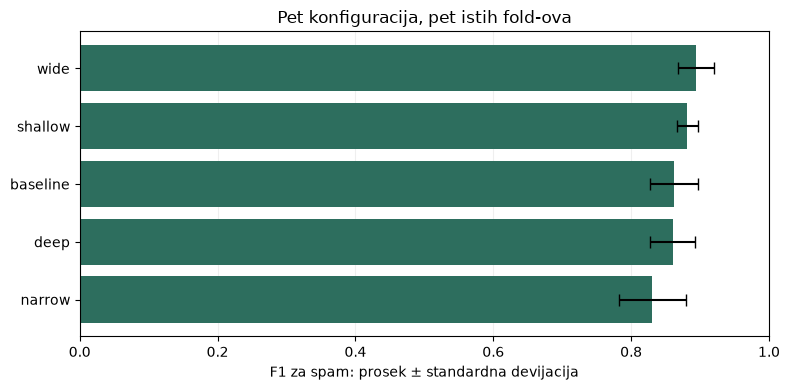

In [21]:
import matplotlib.pyplot as plt

plot_data = configuration_summary.sort_values("srednji_f1")
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(
    plot_data.index, plot_data["srednji_f1"],
    xerr=plot_data["std_f1"], capsize=4, color="#2d6e5e",
)
ax.set_xlim(0, 1)
ax.set_xlabel("F1 za spam: prosek ± standardna devijacija")
ax.set_title("Pet konfiguracija, pet istih fold-ova")
ax.grid(axis="x", alpha=0.2)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()


Po unapred izabranom poređenju posle treće epohe, **wide** ima najveći prosečan F1 za spam: **0,894 ± 0,026**. **Shallow** je blizu sa **0,882 ± 0,015**, a koristi oko **483 hiljade** parametara naspram oko **824 hiljade** kod šireg modela. Kod `wide` prosečan F1 posle druge epohe je čak **0,901**, pa ni broj epoha još nije konačno utvrđen. Razlike između fold-ova i cena modela zaslužuju pažnju pre konačnog izbora. Ovo su samo validacioni rezultati; izabrani model tek treba ponovo trenirati na **svih 4.127 trening poruka**, pa jednom proveriti na izdvojenom testu.
